# Prediksi Estimasi Hari Selesai Target Hafalan Santri
## Pondok Modern Assalam — Metode Random Forest

Notebook ini membangun sistem **prediksi estimasi hari** yang dibutuhkan santri untuk menyelesaikan target hafalannya menggunakan model **Random Forest Regressor**.

**Teknik yang digunakan:**
- StandardScaler untuk normalisasi fitur numerik
- Evaluasi dengan MAE, RMSE, dan R² Score
- Visualisasi Feature Importance

**Fitur Input (X):**
| Kolom | Keterangan |
|---|---|
| Kelas (MTs) | Kelas santri (1, 2, atau 3) |
| Rata-rata Jiyadah/Hari (Ayat) | Rata-rata ayat baru yang disetorkan per hari |
| Frekuensi Setoran/Minggu | Berapa kali santri menyetor per minggu |
| Total Hafalan Saat Ini (Ayat) | Jumlah total ayat yang sudah dihafal |
| Target Hafalan (Ayat) | Target ayat yang harus dicapai |
| Target Hafalan (Juz) | Target dalam satuan juz |
| Rata-rata Nilai Setoran | Nilai rata-rata setoran dari guru (0–100) |

**Output (y):**
- `Estimasi Hari Selesai` — jumlah hari yang dibutuhkan untuk mencapai target hafalan

# 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


# 2. Import Dataset

In [20]:
import pandas as pd # Menambahkan import di sini agar pd dikenali dalam sel ini

# Import dataset dari file Excel — sheet 'Sheet2'
df = pd.read_excel(
    "..//content/data hafalan santri.xlsx",
    sheet_name="Sheet2", # Mengubah nama sheet menjadi 'Sheet2'
    header=2      # Baris ke-3 adalah header kolom
)

# Hapus kolom dengan indeks 0 (kemungkinan 'No') dan 2 (kolom ekstra yang tidak diinginkan)
# Ini disesuaikan berdasarkan df di Kernel State yang menunjukkan 11 kolom,
# dengan kolom 'Nama Santri' berada di indeks 1 yang ingin dipertahankan.
df.drop(columns=[df.columns[0], df.columns[2]], inplace=True)

# Rename kolom agar lebih mudah digunakan, termasuk 'Nama Santri'
# Sekarang df seharusnya memiliki 9 kolom setelah drop 2 kolom.
df.columns = [
    'Nama',
    'Kelas',
    'Jiyadah_per_Hari',
    'Frekuensi_Setoran_Minggu',
    'Total_Hafalan_Ayat',
    'Target_Hafalan_Ayat',
    'Target_Hafalan_Juz',
    'Nilai_Setoran',
    'Estimasi_Hari_Selesai'
]

print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head(10)

Dataset berhasil dimuat: 401 baris, 9 kolom


,Nama,Kelas,Jiyadah_per_Hari,Frekuensi_Setoran_Minggu,Total_Hafalan_Ayat,Target_Hafalan_Ayat,Target_Hafalan_Juz,Nilai_Setoran,Estimasi_Hari_Selesai
0,Aisyah Lutfyani,3,2,564,1203,Al Ikhlas S.d Annaba,6,56,249
1,Ajrina Yusri Ghaisani,12,5,564,1203,Al Ikhlas S.d Annaba,6,89,49
2,Alisha Khaira Wilda Sukoco,15,7,564,1203,Al Ikhlas S.d Annaba,6,99,35
3,Aliyana Dzulhi Setiawan,7,6,564,1203,Al Ikhlas S.d Annaba,6,79,90
4,Alqia Erdiansyah Pradana,3,4,564,1203,Al Ikhlas S.d Annaba,6,62,232
5,Alya Laila Zahra,3,3,564,1203,Al Ikhlas S.d Annaba,6,59,238
6,Alzahra Putriana Herawan,5,3,564,1203,Al Ikhlas S.d Annaba,6,72,136
7,Andara Naysila Azzahra,14,6,564,1203,Al Ikhlas S.d Annaba,6,98,41
8,Anindya Shifa Maharani,5,3,564,1203,Al Ikhlas S.d Annaba,6,72,135
9,Annisa Azwa Noorshafa,10,6,564,1203,Al Ikhlas S.d Annaba,6,80,59


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
print("Ukuran dataset:", df.shape)
print("\nNama kolom:", df.columns.tolist())

Ukuran dataset: (401, 9)

Nama kolom: ['Nama', 'Kelas', 'Jiyadah_per_Hari', 'Frekuensi_Setoran_Minggu', 'Total_Hafalan_Ayat', 'Target_Hafalan_Ayat', 'Target_Hafalan_Juz', 'Nilai_Setoran', 'Estimasi_Hari_Selesai']


# 3. Exploratory Data Analysis (EDA)

In [10]:
df.describe()

,Kelas,Jiyadah_per_Hari,Frekuensi_Setoran_Minggu,Total_Hafalan_Ayat,Target_Hafalan_Juz,Nilai_Setoran,Estimasi_Hari_Selesai
count,401.000000,401.000000,401.000000,401.0,401.0,401.000000,401.000000
mean,8.054863,4.705736,844.783042,1203.0,6.0,77.740648,77.112219
std,3.953730,1.289648,243.551638,0.0,0.0,13.637359,87.965674
min,2.000000,2.000000,564.000000,1203.0,6.0,55.000000,3.000000
25%,5.000000,4.000000,597.000000,1203.0,6.0,65.000000,14.000000
50%,8.000000,5.000000,791.000000,1203.0,6.0,77.000000,47.000000
75%,12.000000,6.000000,1106.000000,1203.0,6.0,90.000000,104.000000
max,15.000000,7.000000,1190.000000,1203.0,6.0,100.000000,370.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Nama                      401 non-null    object
 1   Kelas                     401 non-null    int64 
 2   Jiyadah_per_Hari          401 non-null    int64 
 3   Frekuensi_Setoran_Minggu  401 non-null    int64 
 4   Total_Hafalan_Ayat        401 non-null    int64 
 5   Target_Hafalan_Ayat       401 non-null    object
 6   Target_Hafalan_Juz        401 non-null    int64 
 7   Nilai_Setoran             401 non-null    int64 
 8   Estimasi_Hari_Selesai     401 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 28.3+ KB


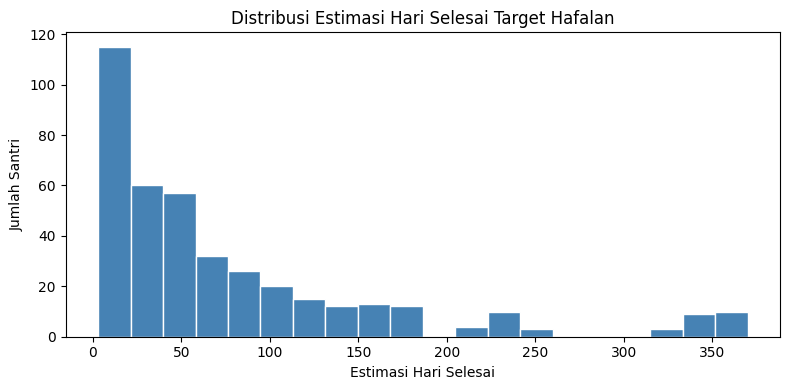

Min : 3 hari
Max : 370 hari
Mean: 77.1 hari


In [12]:
# Konversi kolom 'Estimasi_Hari_Selesai' ke numerik, memaksa kesalahan menjadi NaN
df['Estimasi_Hari_Selesai'] = pd.to_numeric(df['Estimasi_Hari_Selesai'], errors='coerce')

# Hapus nilai NaN dari kolom ini untuk keperluan plot dan perhitungan statistik
estimasi_hari_for_plot = df['Estimasi_Hari_Selesai'].dropna()

# Distribusi Estimasi Hari Selesai (Output/Target)
plt.figure(figsize=(8, 4))
plt.hist(estimasi_hari_for_plot, bins=20, color='steelblue', edgecolor='white')
plt.title('Distribusi Estimasi Hari Selesai Target Hafalan')
plt.xlabel('Estimasi Hari Selesai')
plt.ylabel('Jumlah Santri')
plt.tight_layout()
plt.show()

print(f"Min : {estimasi_hari_for_plot.min()} hari")
print(f"Max : {estimasi_hari_for_plot.max()} hari")
print(f"Mean: {estimasi_hari_for_plot.mean():.1f} hari")

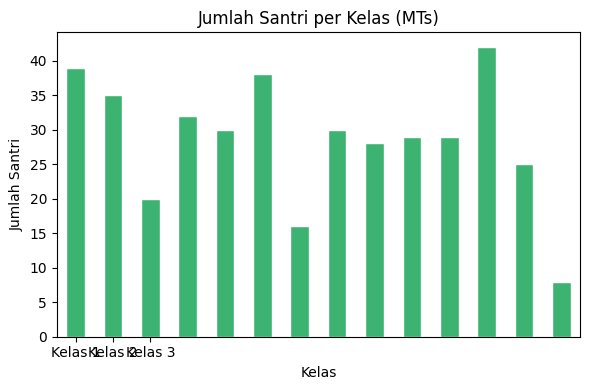

In [13]:
# Distribusi Kelas Santri
plt.figure(figsize=(6, 4))
df['Kelas'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Jumlah Santri per Kelas (MTs)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Santri')
plt.xticks([0, 1, 2], ['Kelas 1', 'Kelas 2', 'Kelas 3'], rotation=0)
plt.tight_layout()
plt.show()

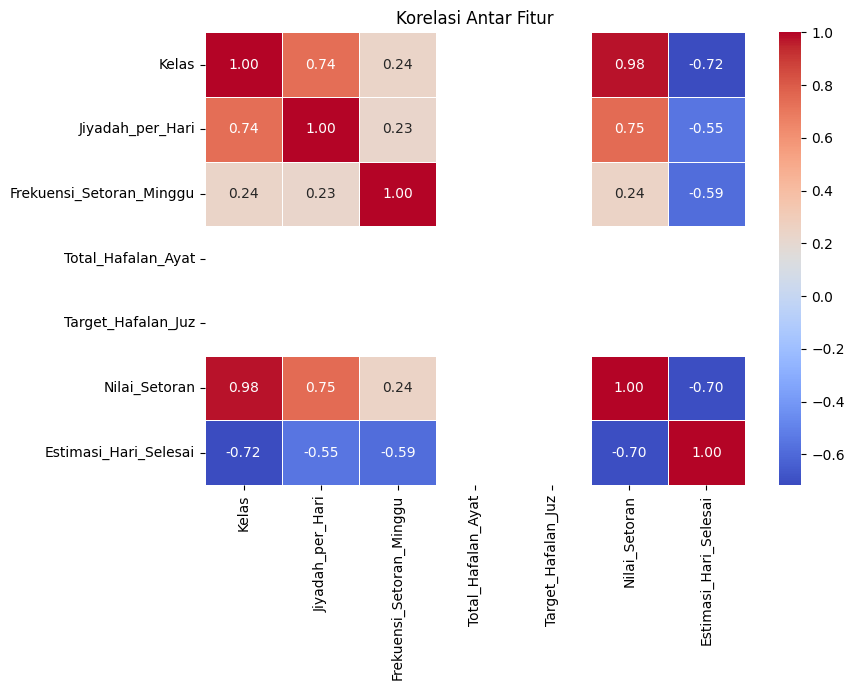

In [14]:
# Korelasi antar fitur
plt.figure(figsize=(9, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

# 4. Data Preprocessing

## 4.1 Cek Nilai Kosong (Missing Values)

In [15]:
print("Jumlah nilai kosong per kolom:")
print(df.isnull().sum())
print(f"\nTotal nilai kosong: {df.isnull().sum().sum()}")

Jumlah nilai kosong per kolom:
Nama                        0
Kelas                       0
Jiyadah_per_Hari            0
Frekuensi_Setoran_Minggu    0
Total_Hafalan_Ayat          0
Target_Hafalan_Ayat         0
Target_Hafalan_Juz          0
Nilai_Setoran               0
Estimasi_Hari_Selesai       0
dtype: int64

Total nilai kosong: 0


In [16]:
# Tampilkan baris yang memiliki nilai kosong (jika ada)
baris_kosong = df[df.isna().any(axis=1)]
print(f"Baris dengan nilai kosong: {len(baris_kosong)}")
if len(baris_kosong) > 0:
    print(baris_kosong)

Baris dengan nilai kosong: 0


## 4.2 Pisahkan Fitur Input (X) dan Target (y)

In [21]:
X = df[[
    'Kelas',
    'Jiyadah_per_Hari',
    'Frekuensi_Setoran_Minggu',
    'Total_Hafalan_Ayat',
    'Target_Hafalan_Juz',
    'Nilai_Setoran'
]].copy()

y = df['Estimasi_Hari_Selesai'].copy()

print("Shape X :", X.shape)
print("Shape y :", y.shape)
X.head()

Shape X : (401, 6)
Shape y : (401,)


,Kelas,Jiyadah_per_Hari,Frekuensi_Setoran_Minggu,Total_Hafalan_Ayat,Target_Hafalan_Juz,Nilai_Setoran
0,3,2,564,1203,6,56
1,12,5,564,1203,6,89
2,15,7,564,1203,6,99
3,7,6,564,1203,6,79
4,3,4,564,1203,6,62


## 4.3 Normalisasi Fitur Numerik

In [22]:
kolom_fitur = X.columns.tolist()

# Ensure X and y are not empty before scaling
if X.empty or y.empty:
    raise ValueError("X or y is empty before scaling. Check previous preprocessing steps.")

# Now, X and y are clean and aligned for scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=kolom_fitur
)

print("Data setelah normalisasi (5 baris pertama):")
X_scaled.head()

Data setelah normalisasi (5 baris pertama):


,Kelas,Jiyadah_per_Hari,Frekuensi_Setoran_Minggu,Total_Hafalan_Ayat,Target_Hafalan_Juz,Nilai_Setoran
0,-1.280102,-2.100663,-1.154309,0.0,0.0,-1.596189
1,0.999073,0.228459,-1.154309,0.0,0.0,0.826657
2,1.758798,1.781207,-1.154309,0.0,0.0,1.560853
3,-0.267135,1.004833,-1.154309,0.0,0.0,0.092461
4,-1.280102,-0.547915,-1.154309,0.0,0.0,-1.155672


In [23]:
# Simpan data yang sudah diproses
import os
os.makedirs('../data/processed', exist_ok=True)
X_scaled.to_csv('../data/processed/Input_Hafalan.csv', index=False)
y.to_csv('../data/processed/Target_Hafalan.csv', index=False)
print("Data berhasil disimpan ke folder processed!")

Data berhasil disimpan ke folder processed!


## 4.4 Split Data Train dan Test (80:20)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"Data Training : {X_train.shape[0]} data ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Data Testing  : {X_test.shape[0]} data ({X_test.shape[0]/len(X)*100:.0f}%)")

Data Training : 320 data (80%)
Data Testing  : 81 data (20%)


# 5. Pembuatan Model Random Forest

In [25]:
# Inisialisasi dan Training Model Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=100,   # Jumlah pohon keputusan
    max_depth=None,     # Kedalaman maksimum (None = tidak dibatasi)
    min_samples_split=2,
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model Random Forest berhasil dilatih!")

✅ Model Random Forest berhasil dilatih!


In [26]:
# Prediksi pada data test
y_pred = model.predict(X_test)

# Sanity Check: Bandingkan prediksi vs aktual
perbandingan = pd.DataFrame({
    'Aktual (Hari)' : y_test.values,
    'Prediksi (Hari)': np.round(y_pred).astype(int),
    'Selisih (Hari)' : np.abs(y_test.values - y_pred).round(1)
})
print("10 Data Pertama:")
print(perbandingan.head(10).to_string(index=False))

10 Data Pertama:
 Aktual (Hari)  Prediksi (Hari)  Selisih (Hari)
             8                6             2.4
            86               84             2.5
           129              134             4.6
            50               45             5.4
            23               26             2.5
            97               94             2.7
           178              169             9.4
            40               42             2.1
            25               27             1.8
           122              118             4.2


# 6. Evaluasi Model

In [27]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("===== Hasil Evaluasi Model =====")
print(f"MAE  (Mean Absolute Error)      : {mae:.2f} hari")
print(f"RMSE (Root Mean Squared Error)  : {rmse:.2f} hari")
print(f"R²   (Koefisien Determinasi)    : {r2:.4f}")
print()
print(f"Interpretasi: Model rata-rata meleset ±{mae:.1f} hari dari estimasi aktual.")

===== Hasil Evaluasi Model =====
MAE  (Mean Absolute Error)      : 3.11 hari
RMSE (Root Mean Squared Error)  : 3.81 hari
R²   (Koefisien Determinasi)    : 0.9981

Interpretasi: Model rata-rata meleset ±3.1 hari dari estimasi aktual.


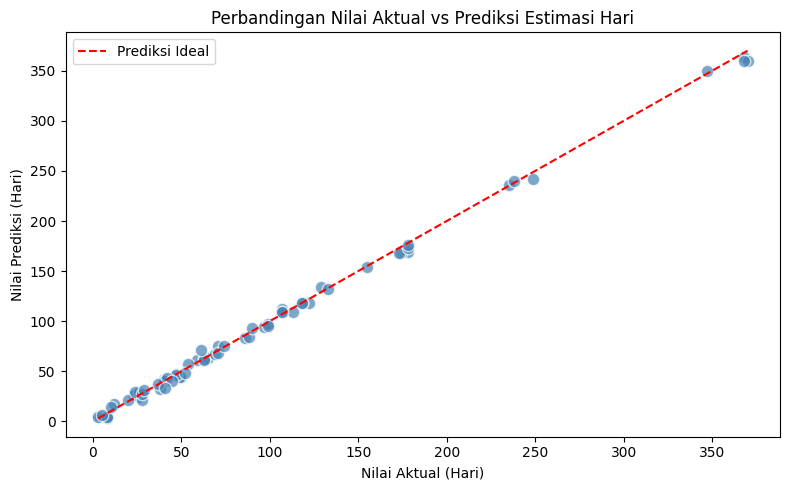

In [28]:
# Visualisasi: Prediksi vs Aktual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolors='white', s=80)
garis_ideal = [y_test.min(), y_test.max()]
plt.plot(garis_ideal, garis_ideal, 'r--', linewidth=1.5, label='Prediksi Ideal')
plt.title('Perbandingan Nilai Aktual vs Prediksi Estimasi Hari')
plt.xlabel('Nilai Aktual (Hari)')
plt.ylabel('Nilai Prediksi (Hari)')
plt.legend()
plt.tight_layout()
plt.show()

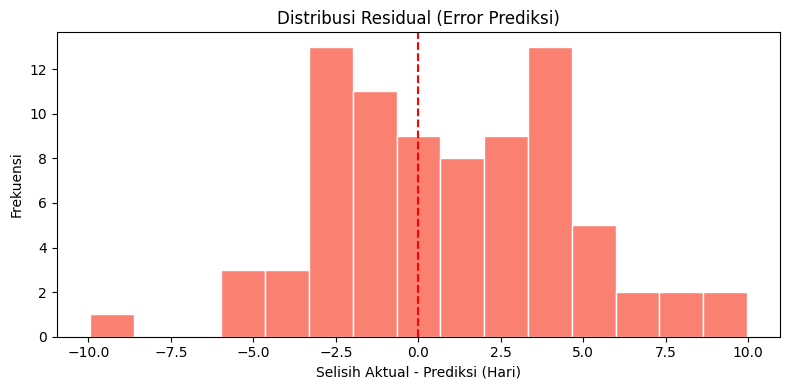

In [29]:
# Visualisasi: Distribusi Error (Residual)
residual = y_test.values - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residual, bins=15, color='salmon', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribusi Residual (Error Prediksi)')
plt.xlabel('Selisih Aktual - Prediksi (Hari)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# 7. Feature Importance

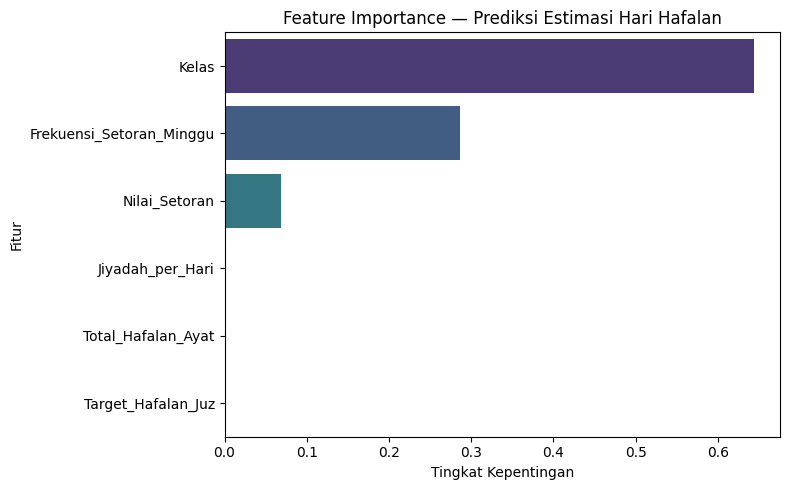

                   Fitur  Importance
                   Kelas    0.643514
Frekuensi_Setoran_Minggu    0.286558
           Nilai_Setoran    0.068799
        Jiyadah_per_Hari    0.001128
      Total_Hafalan_Ayat    0.000000
      Target_Hafalan_Juz    0.000000


In [30]:
fi_df = pd.DataFrame({
    'Fitur'      : kolom_fitur,
    'Importance' : model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=fi_df, x='Importance', y='Fitur', palette='viridis')
plt.title('Feature Importance — Prediksi Estimasi Hari Hafalan')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

# 8. Simpan Model dan Scaler

In [31]:
import os
os.makedirs('../models', exist_ok=True)

# Simpan model
with open('../models/model_hafalan.pkl', 'wb') as f:
    pickle.dump(model, f)

# Simpan scaler
with open('../models/scaler_hafalan.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model dan scaler berhasil disimpan!")

✅ Model dan scaler berhasil disimpan!


# 9. Contoh Prediksi Santri Baru

In [33]:
# Contoh: prediksi estimasi hari untuk santri baru
# Sesuaikan nilai di bawah dengan data santri yang ingin diprediksi

santri_baru = pd.DataFrame([{
    'Kelas'                   : 2,      # Kelas MTs (1/2/3)
    'Jiyadah_per_Hari'        : 8,      # Rata-rata ayat baru per hari
    'Frekuensi_Setoran_Minggu': 5,      # Frekuensi setoran per minggu
    'Total_Hafalan_Ayat'      : 650,    # Total ayat yang sudah dihafal
    'Target_Hafalan_Juz'      : 5.0,    # Target dalam juz
    'Nilai_Setoran'           : 80      # Rata-rata nilai setoran (0–100)
}])

# Preprocessing
santri_baru_scaled = pd.DataFrame(
    scaler.transform(santri_baru[kolom_fitur]), # Filter santri_baru to match the training features
    columns=kolom_fitur
)

# Prediksi
estimasi = model.predict(santri_baru_scaled)[0]

print("===== Hasil Prediksi Santri Baru =====")
print(f"Estimasi hari untuk selesai target : {int(round(estimasi))} hari")
print(f"Estimasi dalam minggu              : ±{int(round(estimasi))//7} minggu")

===== Hasil Prediksi Santri Baru =====
Estimasi hari untuk selesai target : 326 hari
Estimasi dalam minggu              : ±46 minggu
